In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import glob

# Set data paths and plotting style params

In [22]:
figure_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/results/"
data_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/"

In [23]:
font_color = "black"
font_size = 20
plt.rcParams.update(
    {
        "text.color": font_color,
        "axes.labelcolor": font_color,
        "axes.labelsize": font_size,
        "axes.titleweight": "bold",
        "axes.titlesize": font_size,
        "xtick.labelcolor": font_color,
        "xtick.labelsize": font_size,
        "ytick.labelcolor": font_color,
        "ytick.labelsize": font_size,
        "font.weight": "normal",
    })

plt.rc("axes.spines", top=False, bottom=True, left=True, right=False)
plt.rc("axes", edgecolor=font_color)

# functions

In [195]:

def get_signals(dlc, delay = 3, flip_photodiode_singal = -1, std_above_mean=5):
    """
    Processes photodiode and generated signal data from a PROC file and returns a merged DataFrame 
    containing aligned signal and photodiode values.

    Args:
        dlc (dict): A dictionary containing photodiode and signal data. It must include the following keys:
            - 'photodiode_read': Array of photodiode readings.
            - 'photodiode_time': Array of photodiode time points.
            - 'start_time': Single start time value to adjust timestamps.
            - 'frame_time': Array of frame time points corresponding to signals.
            - 'time_stamp': Array of signal time stamps.
            - 'signal': Array of signal readings.
        delay (float, optional): Time delay threshold to scale and process photodiode readings. Default is 3.
        flip_photodiode_signal (int, optional): Factor to flip the polarity of the photodiode signal. 
                                            If using an IC chip photodiode set this to 1.
                                            Default is -1 (inversion of signal).
        std_above_mean (float, optional): Threshold multiplier of standard deviation above the mean 
            for detecting signal changes. Default is 5.

    Returns:
        pd.DataFrame: A DataFrame containing synchronized and processed signal and photodiode data, with the following columns:
            - 'time_stamp': Time stamps 
            - 'send_time': Adjusted signal send times.
            - 'frame_to_socket_time': Absolute difference between the frame and signal send times.
            - 'signal_read': Generated signal values, shifted to frame times 
            - 'photodiode_read': Thresholded photodiode values.
            - 'photodiode_raw_scaled': Scaled raw photodiode readings.

    Notes:
        - The function adjusts the photodiode signal to remove an initial thread-starting point, scales it based on 
          pre-signal mean and max values, and applies a threshold based on the standard deviation of the pre-signal values.
        - The function merges the processed photodiode data with the signal data based on time alignment.
    """
    
    photodiode_read = dlc ["photodiode_read"] *flip_photodiode_singal
    photodiode_time = dlc ["photodiode_time"]- dlc ["start_time"]
    
    # remove first point as this corresponds to the thread starting
    if len(photodiode_time) != len(photodiode_read): 
        photodiode_read = photodiode_read [1:]
    photodiode_read = photodiode_read [photodiode_time > 1]
    photodiode_time = photodiode_time [photodiode_time > 1]
    
    # Calculate the mean value prior to signal coming in to scale the signal and scale the trace 
    min_start = np.mean(photodiode_read [(photodiode_time > 1.5) & (photodiode_time < delay-0.5)])
    photodiode_read = ((photodiode_read-min_start)/(np.max(photodiode_read)-min_start))
    photodiode_signal_scaled = photodiode_read
    
    # Recalculate mean and standard deviation prior to the singal being recieved and threshold based on this
    std_start = np.std(photodiode_read [(photodiode_time > delay-1.5) & (photodiode_time < delay-0.5)])
    mean_start = np.mean(photodiode_read [(photodiode_time > delay-1.5) & (photodiode_time < delay-0.5)])
    photodiode_read = photodiode_read > mean_start + (std_start*std_above_mean)

    signal_time = dlc ["frame_time"]
    send_time = dlc ["time_stamp"]
    signal_read = dlc ["signal"]
    signal_time = signal_time - dlc ["start_time"]
    send_time = send_time - dlc ["start_time"]
    
    #photo_rising_edge = photodiode_time [np.where((np.diff(photodiode_read,prepend=np.nan)> (std_start*1)) == 1)]
    #signal_rising_edge = signal_time [np.where(np.diff(signal_read,append=np.nan) >0.5)]
    signal = pd.DataFrame({"time_stamp": signal_time, "send_time": send_time, "frame_to_socket_time": abs(signal_time-send_time),  "signal_read": signal_read})
    photodiode = pd.DataFrame({"time_stamp": photodiode_time, "photodiode_read": photodiode_read, "photodiode_raw_scaled": photodiode_signal_scaled})
    df = pd.merge_asof(left=photodiode, right=signal, on="time_stamp")
    
    df ["signal_read"]  = df.signal_read.ffill()
    df ["photodiode_read"]  = df.photodiode_read
   
    return(df)


In [196]:
def find_rising_edges(time, signal, threshold=0.9):
    "calculates the rising edges of photodiode and signal."
    rising_edges = []
    for i in range(1, len(signal)):
        if signal[i-1] < threshold and signal[i] >= threshold:
            rising_edges.append(time[i])
    return rising_edges

def get_latency(rising_edges_singal, rising_edges_photodiode):
    
    mini_df_list = []
    for i, r in enumerate(rising_edges_singal[:-1]):
        closest =  np.argmin(abs(r - rising_edges_photodiode[:-1]))
        mini_df_list.append(pd.DataFrame({"frame_time": r,  "photodiode_time": rising_edges_photodiode[closest], "time_diff": rising_edges_photodiode[closest]-r}, index= [i]))
    mini_df  = pd.concat(mini_df_list)
    return(pd.concat(mini_df_list))

In [197]:

def get_latencies(path):
    """
    Processes multiple files containing photodiode and signal data to calculate latencies between rising edges of 
    the signal and the photodiode events, and returns a concatenated DataFrame of latency data for all sessions.

    Args:
        path (str): The file path pattern to load the processed data files. The function searches for files ending with 
        "*PROC" in the specified directory.

    Returns:
        pd.DataFrame: A concatenated DataFrame with latency data from all processed sessions, containing the following columns:
            - 'time_diff': The time difference between the rising edge of the signal and the rising edge of the photodiode event.
            - 'session': The index of the session (file) from which the latencies are computed.
            - 'frame_to_socket': The average difference between time stamps and frame times for the given session.

    Notes:
        - The function loads each processed data file (ending with "*PROC"), extracts the photodiode and signal data using the 
          `get_signals` function, and calculates latencies between the rising edges of the signal and photodiode readings.
        - For each session, it computes the average 'frame_to_socket' time difference, which is the difference between 
          the signal's time stamps and frame times, averaged over a portion of the data.
        - The results for all sessions are concatenated into a single DataFrame.
    """
    
    
    files = glob.glob(path + "*PROC")
    data_list = []
    rate_list = []
    for i, f in enumerate(files):
        print(i, " ", f)
        dlc = np.load(f, allow_pickle=True)
        df = get_signals(dlc)
        # get rising edges of the binarised signals
        rising_edges_a = find_rising_edges(df.time_stamp, df.signal_read)
        rising_edges_photodiode = find_rising_edges(df.time_stamp, df.photodiode_read)
        latencies = get_latency(rising_edges_a, rising_edges_photodiode)
        
        latencies ["session"] =  i
        latencies ["frame_to_socket"] = np.mean(dlc ["time_stamp"][100:]- dlc ["frame_time"][100:] )
        
        data_list.append(latencies)

    return(pd.concat(data_list))



In [198]:
latencies = get_latencies(data_path)
mean_latencies = latencies.groupby(["session"]).mean()
print(mean_latencies.time_diff)

0   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_7_PROC
1   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_6_PROC
2   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_1_PROC
3   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_3_PROC
4   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_2_PROC
5   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_4_PROC
6   /Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/Latency_files/paper_latency_data/Imagingsource_Latency_test_2024-05-29_8_PROC
session
0    0.033800
1    0.034005
2    0.034120
3    0.03437

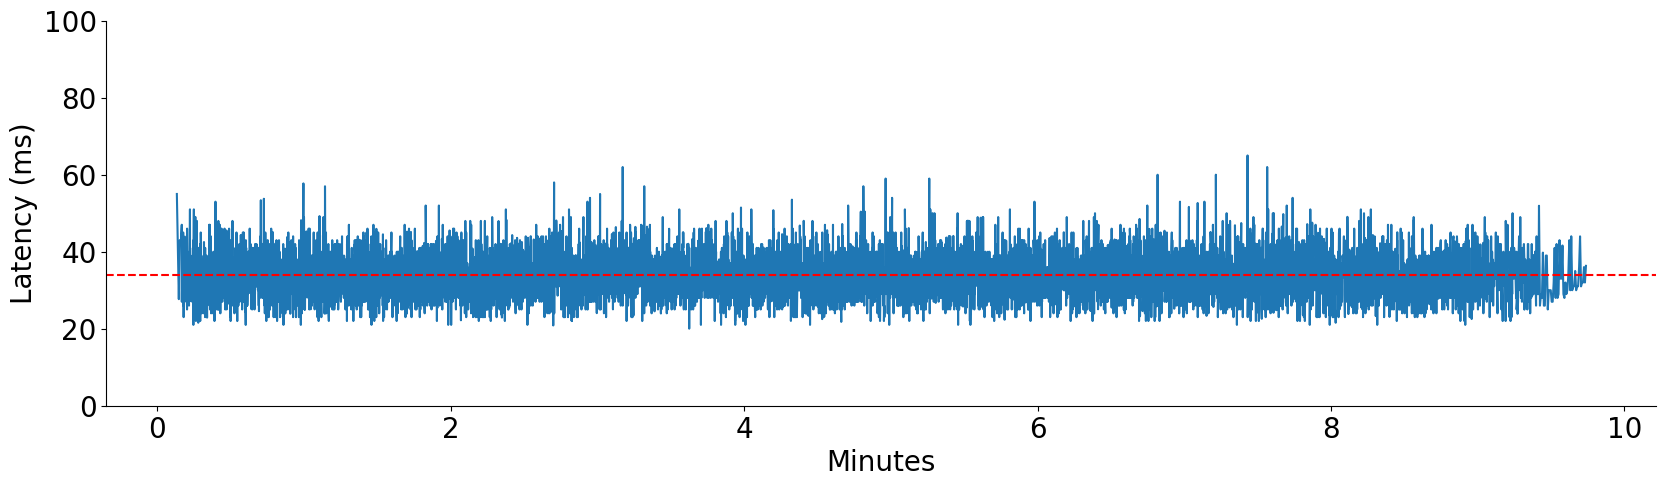

In [178]:
# plot latencies throughout recordings to check that they are stable
plt.figure(figsize=(20,5))
sns.lineplot(latencies, x=latencies.frame_time/60, y=latencies.time_diff*1000)
plt.ylim(0,100)
plt.xlabel("Minutes")
plt.ylabel("Latency (ms)")
plt.axhline(np.mean(latencies.time_diff*1000), c="red", linestyle="dashed")

0.03393414779968393
0.0056600795868742655


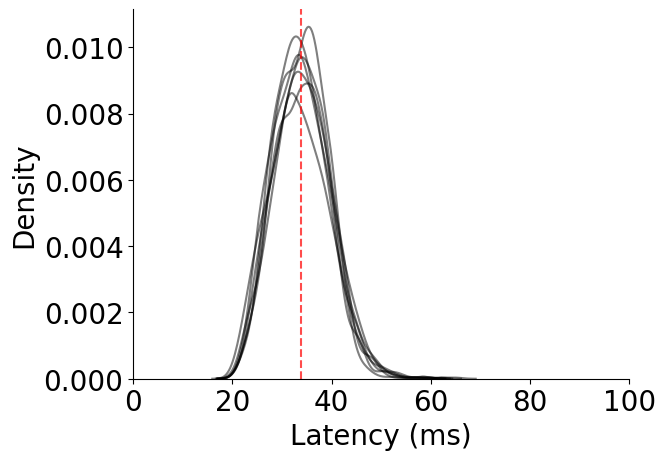

In [199]:
g = sns.kdeplot(data=latencies, x= latencies.time_diff*1000, hue="session", palette=ListedColormap(['black']), alpha=0.5, legend=False)
plt.xlim(0,100)
plt.xlabel("Latency (ms)")
plt.axvline(np.mean(latencies.time_diff*1000), c="red", linestyle="dashed", alpha = 0.7)
print(np.mean(latencies.time_diff))
print(np.std(latencies.time_diff))
plt.savefig(figure_save_path + "roundtrip_latency.svg")

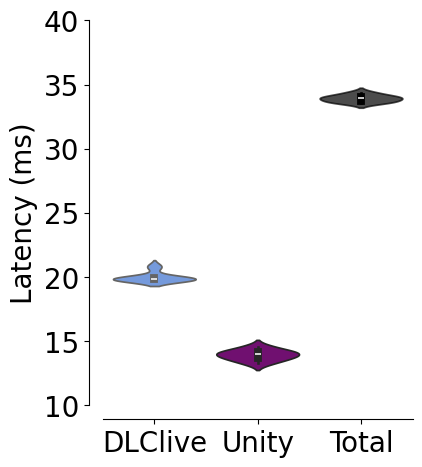

In [200]:
plt.figure(figsize=(4,5))

sns.violinplot(x=np.repeat("DLClive", len(mean_latencies ["time_diff"])), y=abs(mean_latencies ["frame_to_socket"])*1000, color="cornflowerblue")
sns.violinplot(x=np.repeat("Unity", len(mean_latencies ["time_diff"])), y=(abs(mean_latencies ["time_diff"])*1000) - (abs(mean_latencies ["frame_to_socket"])*1000), color="purple")
sns.violinplot(x=np.repeat("Total", len(mean_latencies ["time_diff"])), y=abs(mean_latencies ["time_diff"])*1000, color="black", alpha=0.7)

plt.ylabel("Latency (ms)")
plt.ylim(10,40)
sns.despine(offset=10)
plt.savefig(figure_save_path + "latencies.svg")

In [201]:
# print DLC processing steps latency
print(np.mean(abs(mean_latencies ["frame_to_socket"])*1000))
print(np.std(abs(mean_latencies ["frame_to_socket"])*1000))

19.986868558449622
0.34308513908680816


In [202]:
# Unity render latency
print(np.mean((mean_latencies ["time_diff"]*1000) - (mean_latencies ["frame_to_socket"])*1000))
print(np.std((mean_latencies ["time_diff"]*1000) - (mean_latencies ["frame_to_socket"])*1000))

13.93740930702039
0.3764374324692098


In [203]:
# print total latency
print(np.mean((mean_latencies ["time_diff"])*1000))
print(np.std((mean_latencies ["time_diff"])*1000))

33.92427786547001
0.25810132877963127


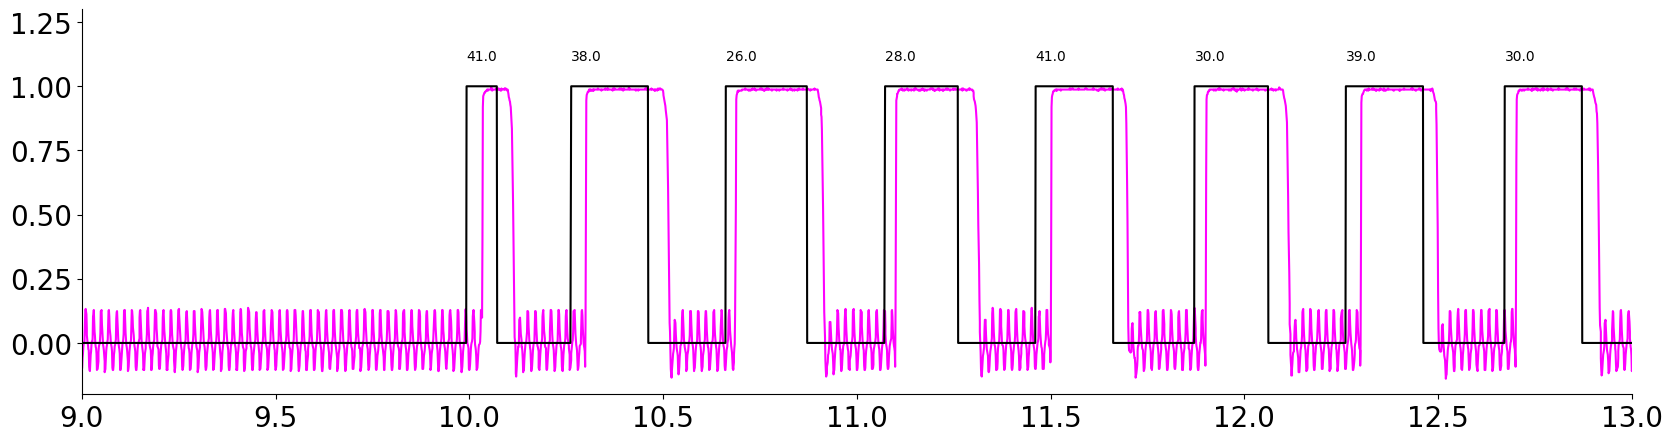

In [217]:
# plot raw data from a single session
files = glob.glob(data_path + "*PROC")
dlc = np.load(files[0], allow_pickle=True)
df = get_signals(dlc)
rising_edges_signal = find_rising_edges(df.time_stamp, df.signal_read)
rising_edges_photodiode = find_rising_edges(df.time_stamp, df.photodiode_read)
latencies = get_latency(rising_edges_signal, rising_edges_photodiode)

plt.figure(figsize=(20,5))
plt.plot(df.time_stamp, df.photodiode_raw_scaled,c="magenta")
plt.plot(df.time_stamp,  df.signal_read, c="black")

for ft, td in zip(latencies.frame_time, latencies.time_diff):
    plt.annotate(round(td*1000, 2), (ft, 1.1))
#print(get_latency(df))
plt.ylim(-0.2,1.3)
plt.xlim(9,13)
plt.savefig(figure_save_path + "signal.svg")

In [189]:
latencies

,frame_time,photodiode_time,time_diff
0,9.992837,10.033835,0.040999
1,10.262835,10.300836,0.038001
2,10.661835,10.687834,0.026000
3,11.072839,11.100836,0.027997
4,11.461399,11.502397,0.040998
...,...,...,...
1366,556.263299,556.298300,0.035002
1367,556.673299,556.711300,0.038001
1368,557.073428,557.111429,0.038001
1369,557.463428,557.512428,0.049001
